In [1]:
from util import go_to_project_root
go_to_project_root()

CWD cambiado a la raíz del proyecto: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/Homeworks


# Tarea 3: SANITY CHECK 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from source.data.sampling import create_time_series
from source.fit import inference as testmodule
from source.display.hw import hw3 as plot_utils
from source.display.hw.hw1 import save_figure
plot_utils.configure_matplotlib_for_latex()

%load_ext autoreload
%autoreload 2

LaTeX está disponible y la configuración se ha aplicado.


### Simulacion


In [4]:
types_of_series = ['stationary', 'unit_root', 'break', 'outlier', 'nonlinear_trend']
nobs = 200
dataset = {}
for kind in types_of_series:
    dataset[kind] = create_time_series(kind, nobs, ss=True, randseed=42) # para que todos los test se comparen con los mismos datos
dataset['t'] = np.linspace(0, 1, nobs)

✅ Figura guardada exitosamente en ./presentation/figures/hw3/simulations.pdf


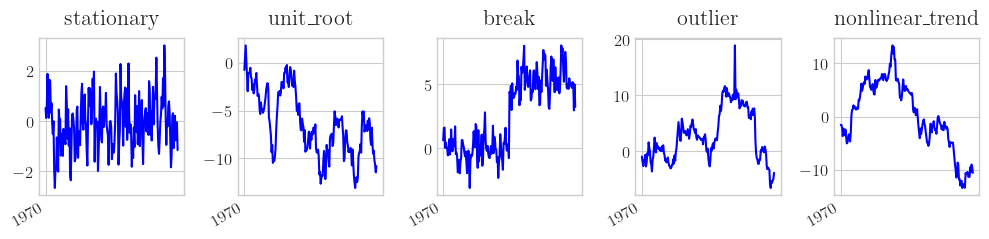

In [6]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=5, 
    figsize=(10, 2.5), 
)
fig, axes = plot_utils.plot_series(dataset, fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/simulations.pdf')

## Test 0: LJung Bx 

In [8]:
resultados_ljung_box = testmodule.test_ljungbox(dataset['stationary'], lags=5)
resultados_ljung_box

Test Ljung-Box


,statistic,p-value
0,47.974956,3.593979e-09


## Test 1: DF (Dickey-Fuller)

In [9]:
metrics = testmodule.test_df(dataset['stationary'])

Test DF


## Test 2: ADF (Augmented Dickey-Fuller)

In [11]:
metrics = testmodule.test_adf(dataset['stationary'])

Test ADF


## Test 3: PP (Phillips-Perron)

In [13]:
metrics = testmodule.test_pp(dataset['stationary'])

Test PP


## Test 4: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [14]:
metrics = testmodule.test_kpss(dataset['stationary'])

Test KPSS


## Test 5: Perron

In [16]:
metrics = testmodule.test_perron(dataset['stationary'])
metrics

Test Perron


,model,statistic,p-value
0,model_a,-7.632630,0.01
0,model_b,-5.286997,0.01
0,model_c,-7.628459,0.01


## Test 6: Zivot-Andrews

In [ ]:
metrics = testmodule.test_zivot_andrews(dataset['stationary'])

Test Zivot-Andrews


## Test 7: Bierens

In [ ]:
metrics = testmodule.test_bierens(dataset['stationary'])

Test Bierens


## Test 8: Murray and Nelson

In [ ]:
metrics = testmodule.test_murray_nelson(dataset['stationary'])

Test Murray-Nelson


## Test 9: GLS detrending

In [ ]:
metrics = testmodule.test_gls(dataset['stationary'])

Test GLS
